In [9]:
pip install openpyxl


  Component ID Component Type                 Model Serial Number  \
0    COMP-0001            APU  Auxiliary Power Unit     SN-688508   
1    COMP-0002   Landing Gear            Brake Unit     SN-498382   
2    COMP-0003         Engine               GEnx-1B     SN-838797   
3    COMP-0004         Engine              CFM56-7B     SN-835911   
4    COMP-0005            APU  Auxiliary Power Unit     SN-158655   

        Manufacturer Aircraft ID Install Date  Flight Hours  Cycles  \
0          Honeywell      AC-100   2025-01-29        6912.0    4638   
1          Honeywell      AC-108   2024-03-05        5550.0    2822   
2  Collins Aerospace      AC-105   2024-09-10        6649.8    5292   
3             Safran      AC-103   2025-03-02        7270.2    5576   
4              Eaton      AC-109   2024-10-12        4319.9    2011   

   Wear Level (%) Condition Status Last Inspection Date Next Inspection Due  \
0            52.7         Marginal           2026-05-14          2027-05-14   


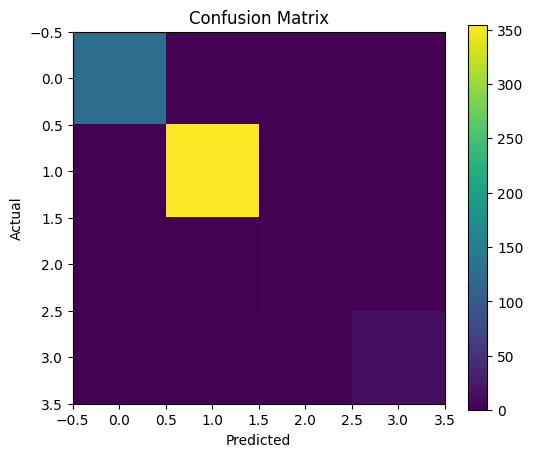

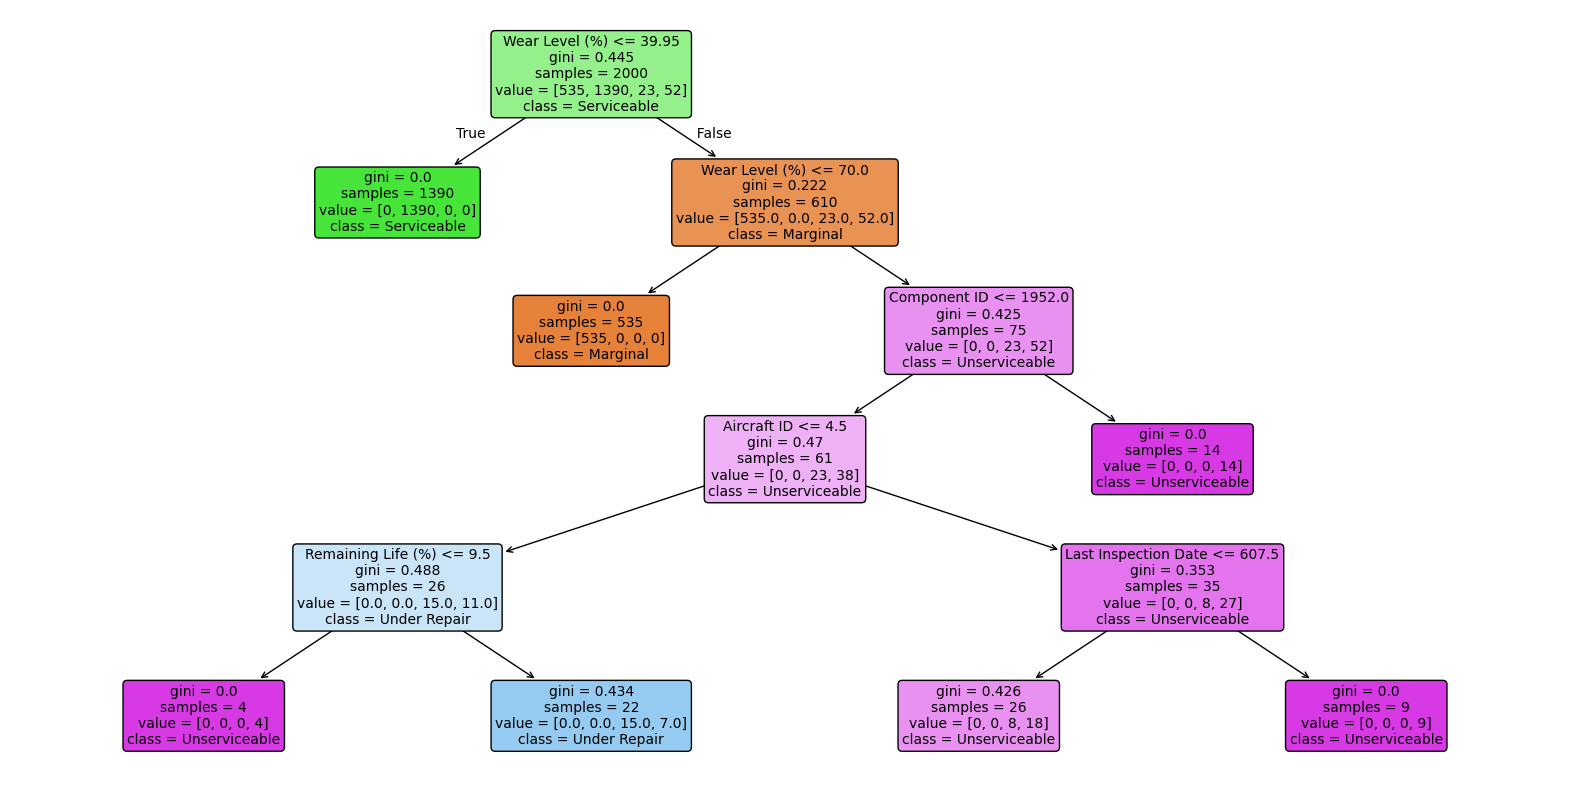

Prediction: [1]
['Serviceable']


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

df = pd.read_excel("/content/flight_components_condition_expanded (1).xlsx")

print(df.head())

print(df.info())

print(df.describe())

df = df.dropna()

# Initialize a specific LabelEncoder for 'Condition Status'
target_encoder = LabelEncoder()
df["Condition Status"] = target_encoder.fit_transform(df["Condition Status"].astype(str))

# Initialize a general LabelEncoder for other object columns
general_encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        # Skip 'Condition Status' as it's already encoded
        if col != "Condition Status":
            df[col] = general_encoder.fit_transform(df[col].astype(str))

X = df.drop("Condition Status", axis=1)
y = df["Condition Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()
plt.figure(figsize=(20,10))

# Use the actual class names from the target_encoder
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in target_encoder.classes_], # Corrected line
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()
sample = X_test.iloc[[0]]

prediction = dt_model.predict(sample)

print("Prediction:", prediction)
print(target_encoder.inverse_transform(prediction))
